In [1]:
# Cellule 1 : Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Cellule 2 : Chargement des données

def load_anssi_data(csv_path='anssi_enriched.csv'):
    try:
        df = pd.read_csv(csv_path)
        df['date_publication'] = pd.to_datetime(df['date_publication'])
        print(f"Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
        return df
    except FileNotFoundError:
        print("Fichier non trouvé")
        return None



def create_mock_data():
    np.random.seed(42)
    n = 100
    
    mock_data = {
        'id_anssi': [f'CERTFR-2024-00{i}' for i in range(1, n+1)],
        'titre': ['Bulletin de sécurité'] * n,
        'type': np.random.choice(['Alerte', 'Avis'], n, p=[0.3, 0.7]),
        'date_publication': pd.date_range('2024-01-01', periods=n, freq='D'),
        'cve': [f'CVE-2024-{1000+i}' for i in range(n)],
        'cvss_score': np.random.uniform(3, 10, n).round(1),
        'epss_score': np.random.uniform(0, 1, n).round(3),
        'editeur': np.random.choice(['Microsoft', 'Apple', 'Google', 'Adobe', 'Linux'], n),
        'produit': np.random.choice(['Windows', 'macOS', 'Chrome', 'Reader', 'Kernel'], n),
        'cwe': np.random.choice(['CWE-79', 'CWE-89', 'CWE-287', 'CWE-22', 'CWE-119'], n),
    }
    
    severity = []
    for score in mock_data['cvss_score']:
        if score >= 9:
            severity.append('Critique')
        elif score >= 7:
            severity.append('Élevée')
        elif score >= 4:
            severity.append('Moyenne')
        else:
            severity.append('Faible')
    mock_data['base_severity'] = severity
    
    df = pd.DataFrame(mock_data)
    print(f"{len(df)} lignes")
    return df


df = create_mock_data()


df.head()


100 lignes


,id_anssi,titre,type,date_publication,cve,cvss_score,epss_score,editeur,produit,cwe,base_severity
0,CERTFR-2024-001,Bulletin de sécurité,Avis,2024-01-01,CVE-2024-1000,3.2,0.642,Linux,macOS,CWE-22,Faible
1,CERTFR-2024-002,Bulletin de sécurité,Avis,2024-01-02,CVE-2024-1001,7.5,0.084,Adobe,macOS,CWE-287,Élevée
2,CERTFR-2024-003,Bulletin de sécurité,Avis,2024-01-03,CVE-2024-1002,5.2,0.162,Google,Chrome,CWE-119,Moyenne
3,CERTFR-2024-004,Bulletin de sécurité,Avis,2024-01-04,CVE-2024-1003,6.6,0.899,Adobe,Windows,CWE-22,Moyenne
4,CERTFR-2024-005,Bulletin de sécurité,Alerte,2024-01-05,CVE-2024-1004,9.4,0.606,Linux,Reader,CWE-287,Critique


In [6]:
# Cellule 3 : Première exploration



print(f"Nb total de vulnérabilités : {len(df)}")
print(f"Nb de colonnes : {df.shape[1]}")
print(f"\nTypes de bulletins :")
print(df['type'].value_counts())
print(f"\nSévérités des vulnérabilités :")
print(df['base_severity'].value_counts())

print("Valeurs manquantes")
print(df.isnull().sum() )


df[['cvss_score', 'epss_score']].describe()

Nb total de vulnérabilités : 100
Nb de colonnes : 11

Types de bulletins :
type
Avis      66
Alerte    34
Name: count, dtype: int64

Sévérités des vulnérabilités :
base_severity
Moyenne     46
Élevée      24
Critique    18
Faible      12
Name: count, dtype: int64
Valeurs manquantes
id_anssi            0
titre               0
type                0
date_publication    0
cve                 0
cvss_score          0
epss_score          0
editeur             0
produit             0
cwe                 0
base_severity       0
dtype: int64


,cvss_score,epss_score
count,100.000000,100.000000
mean,6.485000,0.517570
std,2.051182,0.293446
min,3.000000,0.005000
25%,4.700000,0.277000
50%,6.550000,0.562500
75%,8.350000,0.752000
max,9.900000,0.990000


In [7]:
# Cellule 4 : Fonctions utilitaires pour l'analyse

def get_stats_by_severity(df):
    return df.groupby('base_severity').agg({'cvss_score': ['count', 'mean', 'min', 'max'],'epss_score': 'mean'}).round(3)

def get_top_editeurs(df, n=5):
    return df['editeur'].value_counts().head(n)

def get_top_cwe(df, n=5):
    return df['cwe'].value_counts().head(n)

def cvss_distribution_stats(df):
    return {
        'Critique (9-10)': len(df[df['cvss_score'] >= 9]),
        'Élevée (7-8.9)': len(df[(df['cvss_score'] >= 7) & (df['cvss_score'] < 9)]),
        'Moyenne (4-6.9)': len(df[(df['cvss_score'] >= 4) & (df['cvss_score'] < 7)]),
        'Faible (0-3.9)': len(df[df['cvss_score'] < 4])
    }




print(get_top_editeurs(df))
print("\n")
print(get_stats_by_severity(df))

editeur
Linux        25
Apple        25
Adobe        20
Microsoft    16
Google       14
Name: count, dtype: int64


              cvss_score                  epss_score
                   count   mean  min  max       mean
base_severity                                       
Critique              18  9.400  9.0  9.9      0.431
Faible                12  3.458  3.0  3.8      0.579
Moyenne               46  5.361  4.0  6.9      0.549
Élevée                24  7.967  7.1  8.8      0.493


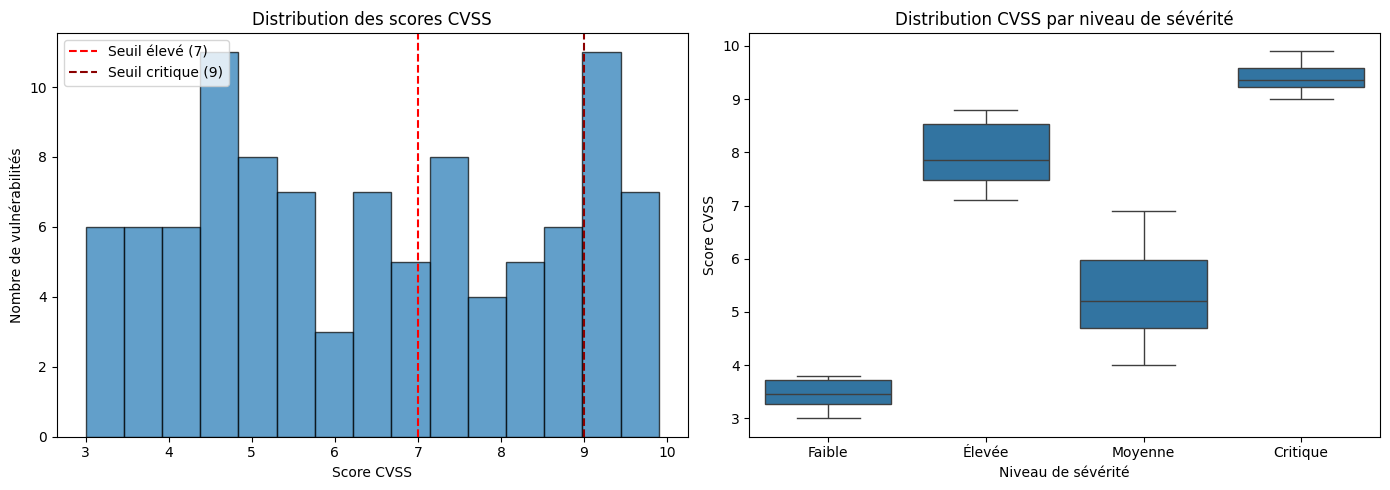

In [8]:
# Cellule 5 : Visualisation test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['cvss_score'], bins=15, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Score CVSS')
axes[0].set_ylabel('Nombre de vulnérabilités')
axes[0].set_title('Distribution des scores CVSS')
axes[0].axvline(x=7, color='red', linestyle='--', label='Seuil élevé (7)')
axes[0].axvline(x=9, color='darkred', linestyle='--', label='Seuil critique (9)')
axes[0].legend()


sns.boxplot(data=df, x='base_severity', y='cvss_score', ax=axes[1])
axes[1].set_xlabel('Niveau de sévérité')
axes[1].set_ylabel('Score CVSS')
axes[1].set_title('Distribution CVSS par niveau de sévérité')

plt.tight_layout()
plt.show()
